In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

In [2]:
val = pd.read_csv("individual project/val.csv")
train  = pd.read_csv("individual project/train.csv")

In [3]:
val.shape

(100, 2)

In [4]:
x_train = train[['x']].values
y_train = train['y'].values
x_val = val[['x']].values
y_val = val['y'].values

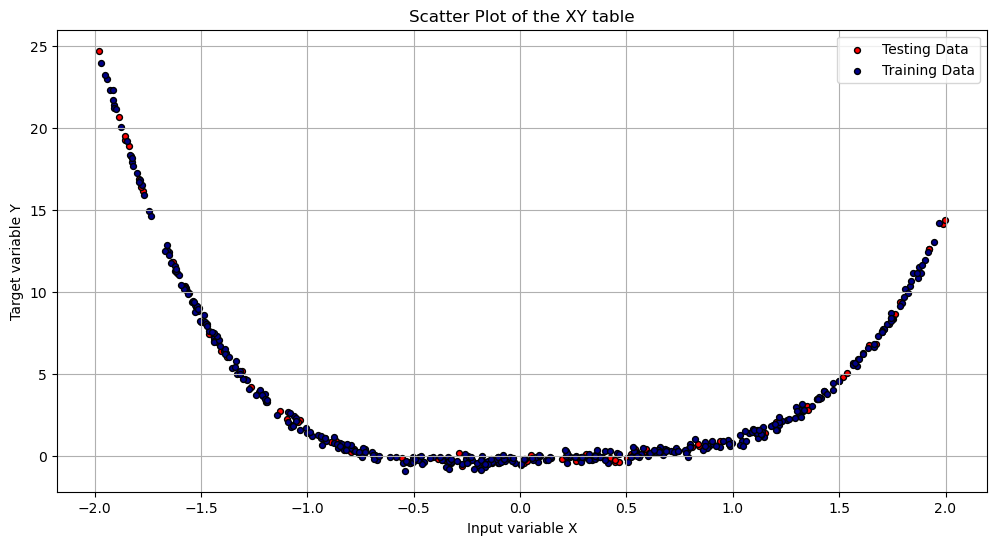

In [5]:
plt.figure(figsize =(12,6))
plt.scatter(x_val,y_val, color = "red", label = "Testing Data", ec = "black", s = 18)
plt.scatter(x_train,y_train, color = "darkblue", label = "Training Data", ec = "black", s=18)
plt.title('Scatter Plot of the XY table')
plt.ylabel("Target variable Y")
plt.xlabel("Input variable X")
plt.legend()
plt.grid(True)
plt.show()

In [6]:
poly = PolynomialFeatures(degree=4, include_bias=False)
x_train_poly = poly.fit_transform(x_train)
x_val_poly = poly.transform(x_val)

In [7]:
model = LinearRegression()
model.fit(x_train_poly, y_train)
y_val_pred = model.predict(x_val_poly)
mse_val = mean_squared_error(y_val, y_val_pred)

In [20]:
intercept = model.intercept_
coefficients = model.coef_

print("Fitted Coefficients:")
print(f"a_0 (Intercept): {intercept:.4f}")
print(f"a_1: {coefficients[0]:.4f}")
print(f"a_2: {coefficients[1]:.4f}")
print(f"a_3: {coefficients[2]:.4f}")
print(f"a_4: {coefficients[3]:.4f}")
print("Validation Error:")
print(f"Mean Squared Error (MSE): {mse_val:.4f}")


Fitted Coefficients:
a_0 (Intercept): -0.2146
a_1: 0.5076
a_2: 0.2899
a_3: -0.8037
a_4: 1.2054
Validation Error:
Mean Squared Error (MSE): 0.0307


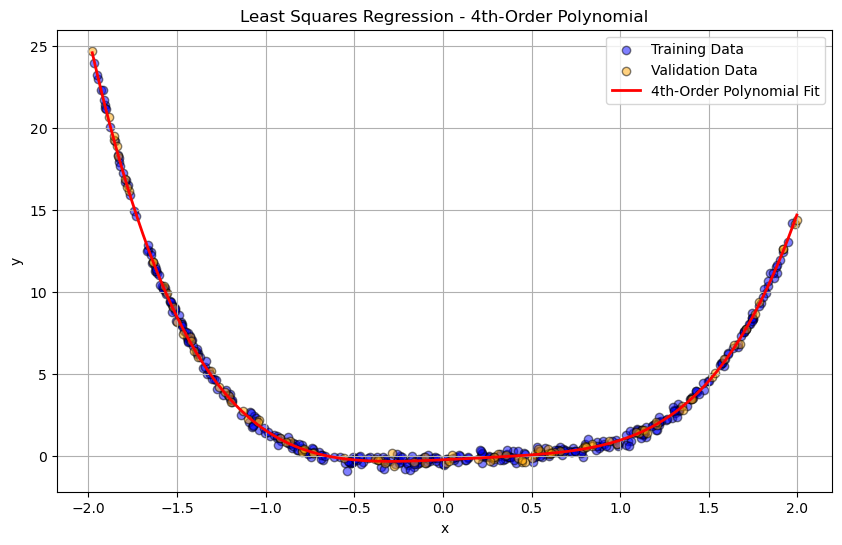

In [22]:
plt.figure(figsize=(10, 6))
plt.scatter(x_train, y_train, label='Training Data', alpha=0.5, color='blue', edgecolor='k')
plt.scatter(x_val, y_val, label='Validation Data', alpha=0.5, color='orange', edgecolor='k')

# Generate a smooth curve for the fitted polynomial
x_range = np.linspace(min(x_train.min(), x_val.min()), max(x_train.max(), x_val.max()), 500).reshape(-1, 1)
x_range_poly = poly.transform(x_range)
y_range_pred = model.predict(x_range_poly)

plt.plot(x_range, y_range_pred, color='red', linewidth=2, label='4th-Order Polynomial Fit')
plt.title('Least Squares Regression - 4th-Order Polynomial')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(True)